In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import spikeinterface.full as si
from pathlib import Path
si.set_global_job_kwargs(n_jobs=0.8, pool_engine='process')

In [3]:
from configuration import base_path
global_name = 'detection_method'

# dataset_name = 'Neuronexus-32_50_300.s'
# dataset_name = 'Neuropixel-128_250_300.s'
dataset_name = 'Neuropixels1-384_500_600.s'

study_folder = base_path / global_name / dataset_name / 'study'
study_folder

PosixPath('/mnt/data/sam/DataSpikeSorting/data_study_components_paper/detection_method/Neuropixels1-384_500_600.s/study')

In [4]:
from spikeinterface.benchmark.benchmark_peak_detection import PeakDetectionStudy
study = PeakDetectionStudy(study_folder)
study

PeakDetectionStudy study 
  datasets: 1 ['static']
  cases: 2 [('locally_exclusive', 'static'), ('matched_filtering', 'static')]
  computed: 2

In [5]:
all_cases = list(study.cases.keys())
all_cases

[('locally_exclusive', 'static'), ('matched_filtering', 'static')]

In [ ]:
study.colors_by_case = {
    ('locally_exclusive', 'static') : "#94D300",
    ('matched_filtering', 'static'): "#2974FF",
}

study.cases[('locally_exclusive', 'static')]['label'] = 'Locally exclusive'
study.cases[('matched_filtering', 'static')]['label'] = 'Matched filtering'


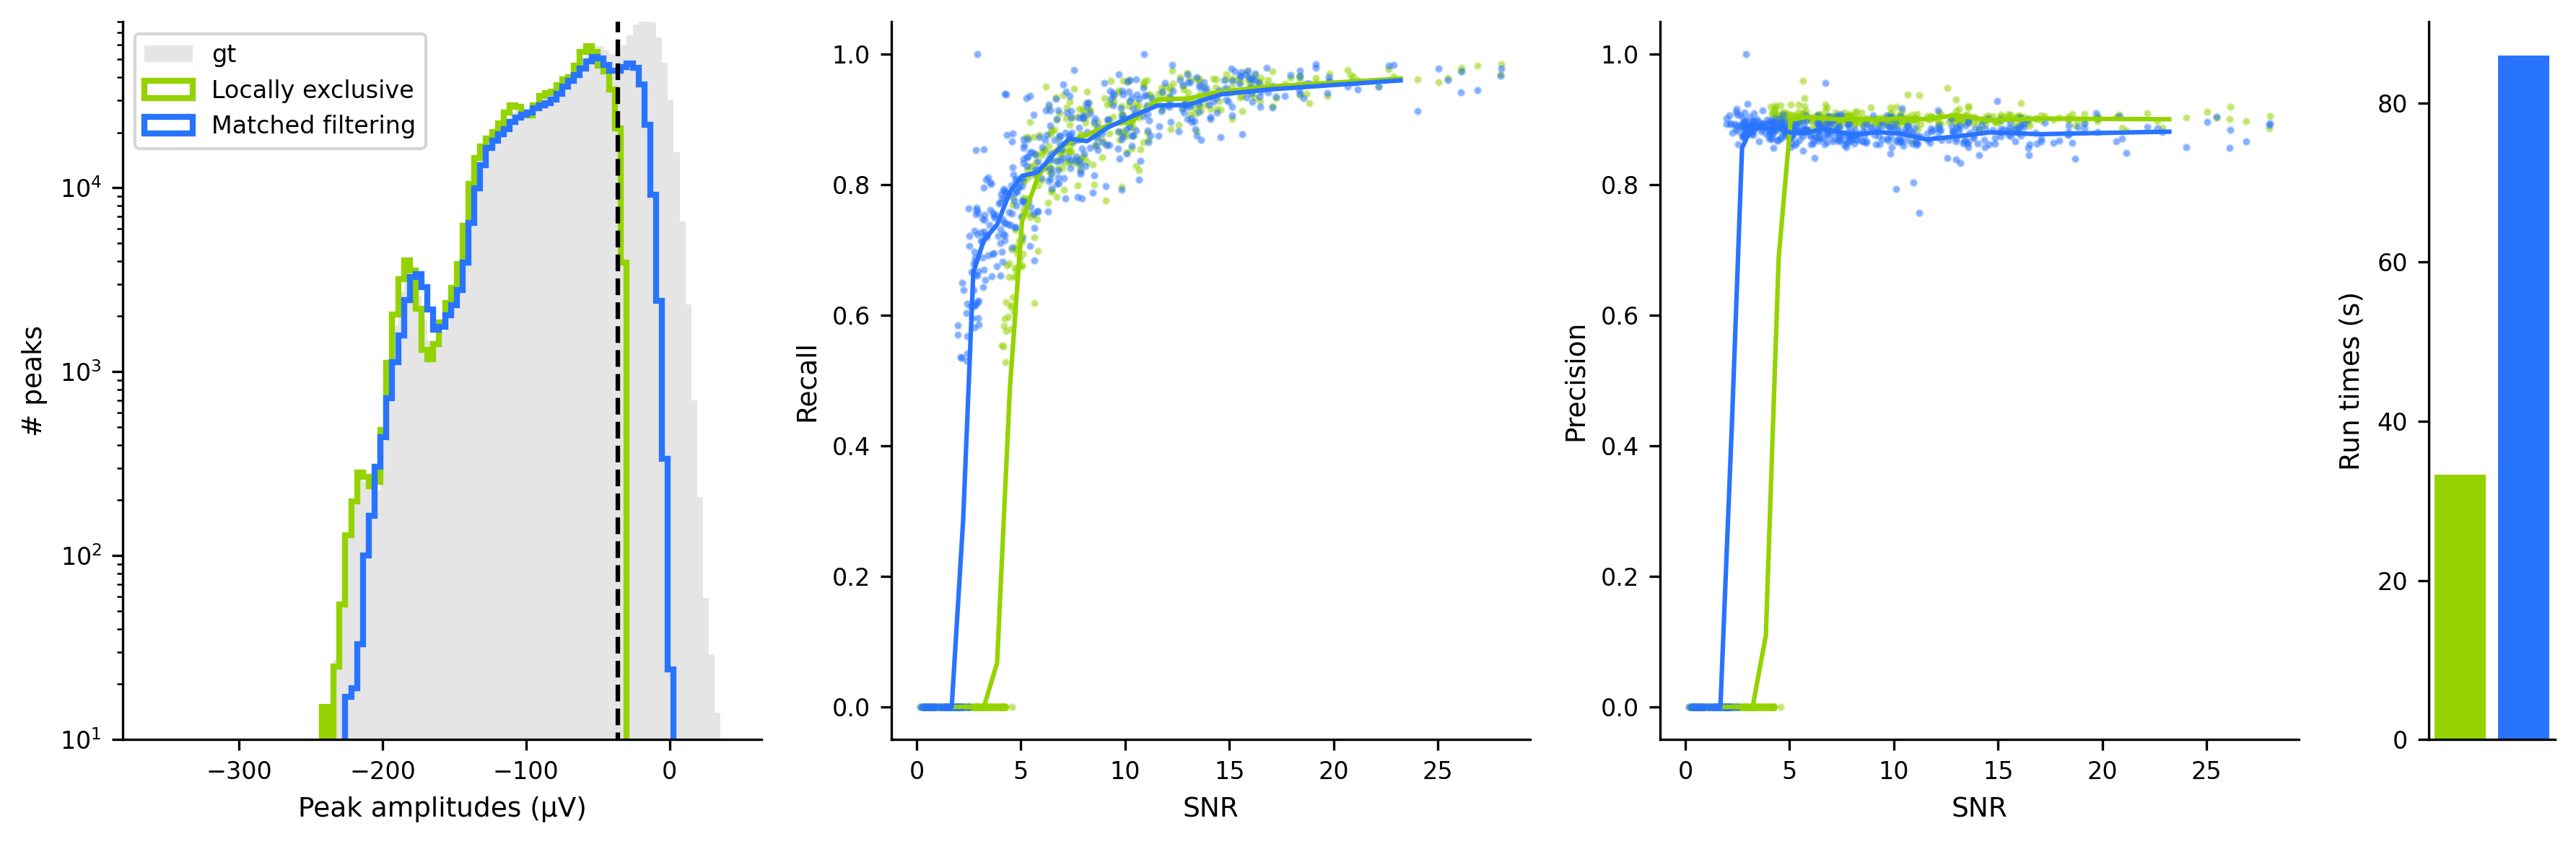

In [ ]:
# %matplotlib widget
myparams = {
    'axes.titlesize' : 10,
    'axes.labelsize' : 9,
    'legend.fontsize': 8,
    'xtick.labelsize' : 8,
    'ytick.labelsize' : 8
}

import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from spikeinterface.benchmark.benchmark_plot_tools import despine, clean_axis, plot_study_legend

with mpl.rc_context(myparams):

    fig = plt.figure(figsize=(12,4), dpi=300)
    
    gs = GridSpec(1, 10)
    ax1 = fig.add_subplot(gs[0, 0:3])
    ax2 = fig.add_subplot(gs[0, 3:6])
    ax3 = fig.add_subplot(gs[0, 6:9])
    ax4 = fig.add_subplot(gs[0, 9 ])

    fig = study.plot_detected_amplitude_distributions(case_keys=all_cases, detect_threshold=5, ax=ax1, show_legend=False)
    ax1.set_xlabel('Peak amplitudes (μV)')
    ax1.set_ylabel('# peaks')
    ax1.legend(loc='upper left')
    ax1.set_ylim(1e1, 8e4)

    fig = study.plot_performances_vs_snr(case_keys=all_cases,
                                         performance_names=("recall",),
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True,
                                        scatter_size=10,
                                        scatter_alpha=0.4,

                                        show_legend=False,
                                         axs=[ax2])
    ax2.set_xlabel('SNR')
    ax2.set_ylabel('Recall')

    fig = study.plot_performances_vs_snr(case_keys=all_cases,
                                        performance_names=("precision",),
                                        with_sigmoid_fit=False,
                                        show_average_by_bin=True,
                                        scatter_size=10,
                                        scatter_alpha=0.4,

                                        show_legend=False,
                                         axs=[ax3])
    ax3.set_xlabel('SNR')
    ax3.set_ylabel('Precision')


    fig = study.plot_run_times(case_keys=all_cases, ax=ax4)
    ax4.set_xticks([])
    despine(ax4)

    fig.tight_layout()



    fig.savefig('/home/samuel.garcia/figures_paper_v2/figure_detection.png')
    fig.savefig('/home/samuel.garcia/figures_paper_v2/figure_detection.pdf')